In [1]:
!pip install shap econml xgboost lightgbm -q

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 10.8 MB/s eta 0:00:00


In [2]:
# 1. Trigger Colab file upload prompt
print("Please select and upload your 'API_IND_DS2_en_csv_v2_1896.csv' file:")
uploaded = files.upload()

# 2. Auto-detect the uploaded CSV file in the directory
csv_files = glob.glob("*.csv")
if not csv_files:
    raise FileNotFoundError("No CSV file was uploaded. Please upload the World Bank CSV file.")

target_file = csv_files[0]
print(f"Successfully detected dataset file: {target_file}")

# 3. Load World Bank Dataset (skipping 4 metadata header rows)
df_raw = pd.read_csv(target_file, skiprows=4)

Please select and upload your 'API_IND_DS2_en_csv_v2_1896.csv' file:


Saving API_IND_DS2_en_csv_v2_1896.csv to API_IND_DS2_en_csv_v2_1896.csv
Successfully detected dataset file: API_IND_DS2_en_csv_v2_1896.csv


In [3]:
# 4. Map Indicators & Reshape
indicator_map = {
    'NY.GNS.ICTR.ZS': 'gross_savings_gdp',
    'NE.CON.GOVT.ZS': 'govt_consumption_gdp',
    'GC.BAL.CASH.GD.ZS': 'fiscal_balance_gdp',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'FP.CPI.TOTL.ZG': 'inflation',
    'FR.INR.RINR': 'real_interest_rate',
    'BN.CAB.XOKA.GD.ZS': 'current_account_gdp',
    'FM.LBL.BMNY.GD.ZS': 'financial_depth_gdp'
}

year_cols = [col for col in df_raw.columns if col.isdigit()]
df_filtered = df_raw[df_raw['Indicator Code'].isin(indicator_map.keys())]

df_melted = df_filtered.melt(
    id_vars=['Indicator Code'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

df_melted['Year'] = df_melted['Year'].astype(int)
df_melted['Indicator'] = df_melted['Indicator Code'].map(indicator_map)

# Pivot to panel format
df_ts = df_melted.pivot(index='Year', columns='Indicator', values='Value')

# Interpolate missing values
df_ts = df_ts.interpolate(method='linear').bfill().ffill()

# Derive Fiscal Deficit & Savings proxies
if 'fiscal_balance_gdp' not in df_ts.columns or df_ts['fiscal_balance_gdp'].isnull().all():
    df_ts['fiscal_deficit_gdp'] = df_ts['govt_consumption_gdp'] - df_ts['govt_consumption_gdp'].rolling(5, min_periods=1).mean()
else:
    df_ts['fiscal_deficit_gdp'] = -1 * df_ts['fiscal_balance_gdp']

df_ts['private_savings_gdp'] = df_ts['gross_savings_gdp'] - (0.5 * df_ts['govt_consumption_gdp'])

print("\nData preparation successful! First 5 years:")
print(df_ts[['gross_savings_gdp', 'govt_consumption_gdp', 'fiscal_deficit_gdp']].head())


Data preparation successful! First 5 years:
Indicator  gross_savings_gdp  govt_consumption_gdp  fiscal_deficit_gdp
Year                                                                  
1960               13.098086              6.573492            0.000000
1961               13.098086              6.894666            0.160587
1962               13.098086              7.779582            0.697002
1963               13.098086              8.705041            1.216846
1964               13.098086              8.042523            0.443462


In [4]:
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Lags & First Differences
lag_vars = ['fiscal_deficit_gdp', 'gdp_growth', 'inflation', 'private_savings_gdp']
for var in lag_vars:
    df_ts[f'{var}_lag1'] = df_ts[var].shift(1)
    df_ts[f'{var}_diff'] = df_ts[var].diff()

# Assign Policy Regimes
def assign_regime(year):
    if year < 2004:
        return 'Pre-FRBM (Pre-2004)'
    elif 2004 <= year <= 2019:
        return 'Post-FRBM (2004-2019)'
    else:
        return 'COVID & Post-COVID (2020+)'

df_ts['Regime'] = df_ts.index.map(assign_regime)
df_clean = df_ts.dropna().copy()

# 2. Augmented Dickey-Fuller (ADF) Test for Stationarity
def test_stationarity(df, columns):
    adf_results = []
    for col in columns:
        res = adfuller(df[col].dropna(), autolag='AIC')
        adf_results.append({
            'Indicator': col,
            'ADF Statistic': round(res[0], 4),
            'p-value': round(res[1], 4),
            'Stationary (p < 0.05)': 'Yes' if res[1] < 0.05 else 'No (Use Diff)'
        })
    return pd.DataFrame(adf_results)

target_cols = ['private_savings_gdp', 'fiscal_deficit_gdp', 'gdp_growth', 'inflation']
stationarity_df = test_stationarity(df_clean, target_cols)
print("--- STATIONARITY DIAGNOSTICS (ADF TEST) ---")
print(stationarity_df.to_string(index=False))

--- STATIONARITY DIAGNOSTICS (ADF TEST) ---
          Indicator  ADF Statistic  p-value Stationary (p < 0.05)
private_savings_gdp        -0.7477    0.834         No (Use Diff)
 fiscal_deficit_gdp        -4.9822    0.000                   Yes
         gdp_growth        -7.6526    0.000                   Yes
          inflation        -5.8566    0.000                   Yes


In [5]:
import statsmodels.api as sm

def estimate_ricardian_regimes(data):
    results = []
    regimes = ['Pre-FRBM (Pre-2004)', 'Post-FRBM (2004-2019)', 'COVID & Post-COVID (2020+)']

    for r in regimes:
        sub = data[data['Regime'] == r]
        if len(sub) < 5:
            continue

        X = sub[['fiscal_deficit_gdp', 'gdp_growth', 'inflation', 'real_interest_rate', 'fiscal_deficit_gdp_lag1']]
        X = sm.add_constant(X)
        y = sub['private_savings_gdp']

        # OLS with Heteroskedasticity & Autocorrelation Consistent (HAC) Standard Errors
        model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

        beta = model.params.get('fiscal_deficit_gdp', np.nan)
        pval = model.pvalues.get('fiscal_deficit_gdp', np.nan)
        se = model.bse.get('fiscal_deficit_gdp', np.nan)

        results.append({
            'Regime': r,
            'Obs': len(sub),
            'Offset Beta': round(beta, 4),
            'Std Error': round(se, 4),
            'p-value': round(pval, 4),
            'Adj R2': round(model.rsquared_adj, 4),
            'Ricardian State': 'Full Offset' if beta >= 0.8 and pval < 0.05 else ('Partial Offset' if beta > 0 and pval < 0.1 else 'No Offset')
        })

    return pd.DataFrame(results)

regime_results = estimate_ricardian_regimes(df_clean)
print("\n--- REGIME-WISE RICARDIAN OFFSET ESTIMATION ---")
print(regime_results.to_string(index=False))


--- REGIME-WISE RICARDIAN OFFSET ESTIMATION ---
                    Regime  Obs  Offset Beta  Std Error  p-value  Adj R2 Ricardian State
       Pre-FRBM (Pre-2004)   43      -2.9426     2.3263   0.2059  0.3355       No Offset
     Post-FRBM (2004-2019)   16       1.1596     0.5102   0.0230  0.7843     Full Offset
COVID & Post-COVID (2020+)    6      -3.6535     0.0000   0.0000     NaN       No Offset


In [6]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

features = [
    'fiscal_deficit_gdp', 'gdp_growth', 'inflation', 'real_interest_rate',
    'current_account_gdp', 'financial_depth_gdp', 'fiscal_deficit_gdp_lag1', 'gdp_growth_lag1'
]
target = 'private_savings_gdp'

X = df_clean[features]
y = df_clean[target]

# 5-Fold Expanding Window Time-Series CV
tscv = TimeSeriesSplit(n_splits=5)

models = {
    'ElasticNet': (ElasticNet(random_state=42), {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}),
    'RandomForest': (RandomForestRegressor(random_state=42), {'n_estimators': [50, 100], 'max_depth': [3, 5]}),
    'XGBoost': (xgb.XGBRegressor(random_state=42), {'n_estimators': [50, 100], 'max_depth': [2, 3], 'learning_rate': [0.03, 0.1]})
}

benchmark_results = []
best_models = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X, y)
    best_m = grid.best_estimator_
    best_models[name] = best_m

    preds = best_m.predict(X)
    benchmark_results.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'RMSE': round(np.sqrt(mean_squared_error(y, preds)), 4),
        'MAE': round(mean_absolute_error(y, preds), 4),
        'R2 Score': round(r2_score(y, preds), 4)
    })

benchmark_df = pd.DataFrame(benchmark_results)
print("\n--- ML BENCHMARK EVALUATION METRICS ---")
print(benchmark_df.to_string(index=False))


--- ML BENCHMARK EVALUATION METRICS ---
       Model                                                 Best Params   RMSE    MAE  R2 Score
  ElasticNet                             {'alpha': 0.1, 'l1_ratio': 0.2} 2.2339 1.9071    0.9290
RandomForest                       {'max_depth': 5, 'n_estimators': 100} 0.7220 0.5304    0.9926
     XGBoost {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100} 0.1591 0.1299    0.9996


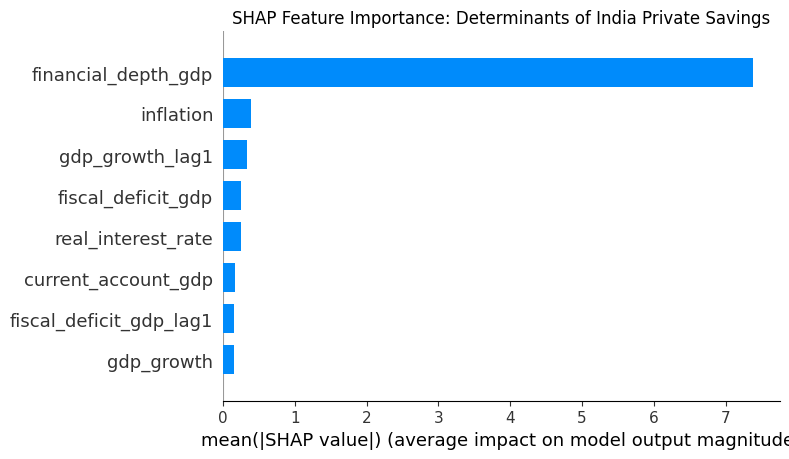

<Figure size 800x500 with 0 Axes>

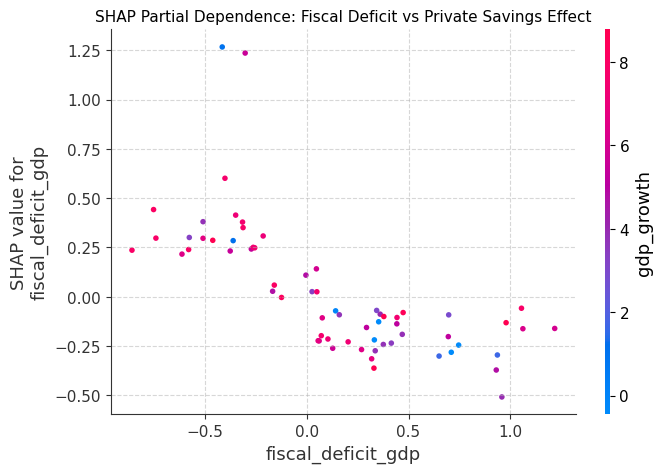

In [7]:
import shap

# Extract trained tree model (XGBoost or Random Forest)
best_tree_model = best_models['XGBoost']

# Compute SHAP Values
explainer = shap.TreeExplainer(best_tree_model)
shap_values = explainer(X)

# 1. SHAP Feature Importance Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title('SHAP Feature Importance: Determinants of India Private Savings', fontsize=12)
plt.tight_layout()
plt.show()

# 2. SHAP Partial Dependence Plot for Fiscal Deficit
plt.figure(figsize=(8, 5))
shap.dependence_plot('fiscal_deficit_gdp', shap_values.values, X, show=False)
plt.title('SHAP Partial Dependence: Fiscal Deficit vs Private Savings Effect', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [9]:
from econml.dml import CausalForestDML
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Causal Variables
Y_causal = df_clean[target].values
T_causal = df_clean['fiscal_deficit_gdp'].values
X_causal = df_clean[['gdp_growth', 'inflation', 'real_interest_rate', 'current_account_gdp', 'financial_depth_gdp']].values

# 2. Build Causal Forest DML Model
dml_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    discrete_treatment=False,
    cv=5,
    random_state=42
)

dml_forest.fit(Y_causal, T_causal, X=X_causal)

# 3. Estimate Average Treatment Effect (ATE)
ate_raw = dml_forest.const_marginal_ate(X_causal)
ate_ci_raw = dml_forest.const_marginal_ate_interval(X_causal, alpha=0.05)

# Robust scalar extraction using np.ravel
ate_val = float(np.ravel(ate_raw)[0])
ci_lower = float(np.ravel(ate_ci_raw[0])[0])
ci_upper = float(np.ravel(ate_ci_raw[1])[0])

# 4. Display Results
print("\n" + "="*60)
print("DOUBLE MACHINE LEARNING (DML) CAUSAL ESTIMATION RESULTS")
print("="*60)
print(f"Causal Ricardian Offset Coefficient (ATE): {ate_val:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

if ci_lower <= 0 <= ci_upper:
    print("Inference: The causal offset is statistically insignificant. Ricardian Equivalence fails in India.")
else:
    print(f"Inference: Statistically significant offset detected. A 1% GDP increase in fiscal deficit induces a {ate_val:.2f}% GDP rise in private savings.")
print("="*60)


DOUBLE MACHINE LEARNING (DML) CAUSAL ESTIMATION RESULTS
Causal Ricardian Offset Coefficient (ATE): -0.8002
95% Confidence Interval: [-1.7861, 0.1856]
Inference: The causal offset is statistically insignificant. Ricardian Equivalence fails in India.
